# Automated Typeplate Recognition — OCR Model Comparison
**Mitchel Wouters | 15235076 | Bachelor AI | UvA / HvA Maintenancelab**

This notebook covers:
1. Data exploration of the labeled testset
2. Baseline: Tesseract OCR (Smith, 2007) — replicates Prognotice/Ivar pipeline
3. Candidate model 1: EasyOCR (JaidedAI, 2020)
4. Candidate model 2: PaddleOCR / PP-OCR (Du et al., 2020, arXiv:2009.09941)
5. Evaluation and comparison across all models

**Evaluation methodology** follows Bourne et al. (2026, arXiv:2604.06160):
- Primary metric: Character Error Rate (CER) via Levenshtein distance on full transcription
- Secondary metric: Word Error Rate (WER)
- Structured metric: Field-level F1 (precision, recall, exact match per field)
- Constraint metric: Processing time per image (target ≤ 6s, per Prognotice requirement)

## 0. Imports and configuration

In [ ]:
import os, re, time, warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
from jiwer import cer, wer

# ── Paths — adjust if needed ────────────────────────────────────────────
GT_EXCEL  = r"C:/Users/mitch/OneDrive/Documenten/uni/3.4 scriptie/labeled_testset.xlsx"
IMAGE_DIR = r"C:/Users/mitch/Downloads/Online data typeplaatjes/testset"

# ── Evaluation settings ─────────────────────────────────────────────────
# Only rows with status=OK are used. CHECK rows have uncertain ground truth.
FILTER_STATUS = "OK"

# Fields used for structured (field-level F1) evaluation
FIELDS = ["brand", "model", "serial_number", "build_year", "power_output"]

# ── jiwer transforms: lowercase + strip whitespace before CER/WER ───────
from jiwer import transforms as tr
TRANSFORMS = tr.Compose([
    tr.ToLowerCase(),
    tr.Strip(),
    tr.ReduceToListOfListOfChars()
])

print("Imports OK")

Imports OK


## 1. Data exploration

In [4]:
df_raw = pd.read_excel(GT_EXCEL)
print(f"Shape: {df_raw.shape}")
display(df_raw.head(5))

Shape: (150, 12)


,batch_id,filename,transcription,brand,model,serial_number,build_year,power_output,plate_type,readability,status,notes
0,batch_01,imgi_96_s-l1200.jpg,"FLOWSERVE CORP. RALEIGH, NC 27603. BOLTED BONN...",Flowserve,B16.34LTD,26012160000000,2006.0,NaN,engraved,good,OK,Datum afgeleid uit DATE OF MFR 7/2006. Power o...
1,batch_01,imgi_97_s-l400.jpg,Dayton. Industrial Control Transformer. Model:...,Dayton,31EH75,NaN,NaN,50VA,sticker,good,OK,Serial number niet zichtbaar/aanwezig. Vermoge...
2,batch_01,imgi_9_default (2).jpg,WESTINGHOUSE. Life Line Heater. Type AR-2. Hea...,Westinghouse,AR-2,NaN,NaN,NaN,metal_plate,medium,CHECK,Kleine afbeelding; veel tabelwaarden zijn te k...
3,batch_01,imgi_9_default (8).jpg,FLOWSERVE Pump Division. Serial N° 79799. Mode...,Flowserve,K4RP-11,79799,2008.0,267.5,sticker,medium,CHECK,Enkele velden zijn lastig leesbaar door lage r...
4,batch_01,imgi_9_default (9).jpg,J.K. TRANSFORMERS & SWITCHGEARS. TYPE LOAD BAN...,J.K. Transformers & Switchgears,NaN,NaN,NaN,NaN,metal_plate,poor,CHECK,Afbeelding is te klein; alleen merk betrouwbaa...


In [5]:
print(df_raw.info())
print()
print(df_raw.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   batch_id       150 non-null    object 
 1   filename       150 non-null    object 
 2   transcription  150 non-null    object 
 3   brand          137 non-null    object 
 4   model          119 non-null    object 
 5   serial_number  88 non-null     object 
 6   build_year     47 non-null     float64
 7   power_output   55 non-null     object 
 8   plate_type     150 non-null    object 
 9   readability    150 non-null    object 
 10  status         150 non-null    object 
 11  notes          150 non-null    object 
dtypes: float64(1), object(11)
memory usage: 14.2+ KB
None

        batch_id             filename  \
count        150                  150   
unique        15                  149   
top     batch_01  imgi_80_s-l1200.jpg   
freq          11                    2   
mean         N

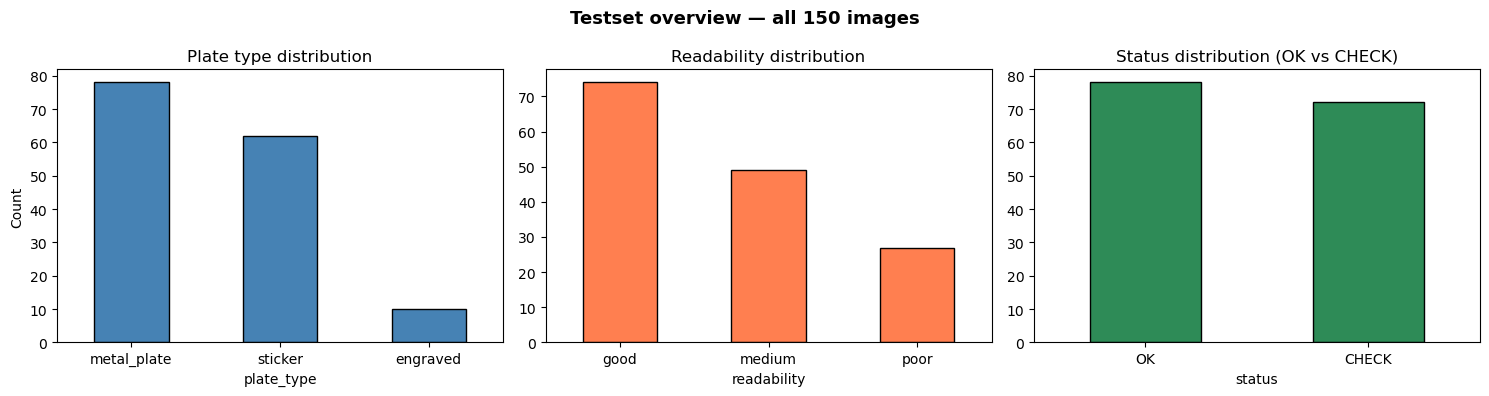

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df_raw["plate_type"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("Plate type distribution")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=0)

df_raw["readability"].value_counts().plot(kind="bar", ax=axes[1], color="coral", edgecolor="black")
axes[1].set_title("Readability distribution")
axes[1].tick_params(axis='x', rotation=0)

df_raw["status"].value_counts().plot(kind="bar", ax=axes[2], color="seagreen", edgecolor="black")
axes[2].set_title("Status distribution (OK vs CHECK)")
axes[2].tick_params(axis='x', rotation=0)

plt.suptitle("Testset overview — all 150 images", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("fig_testset_overview.png", dpi=150, bbox_inches='tight')
plt.show()

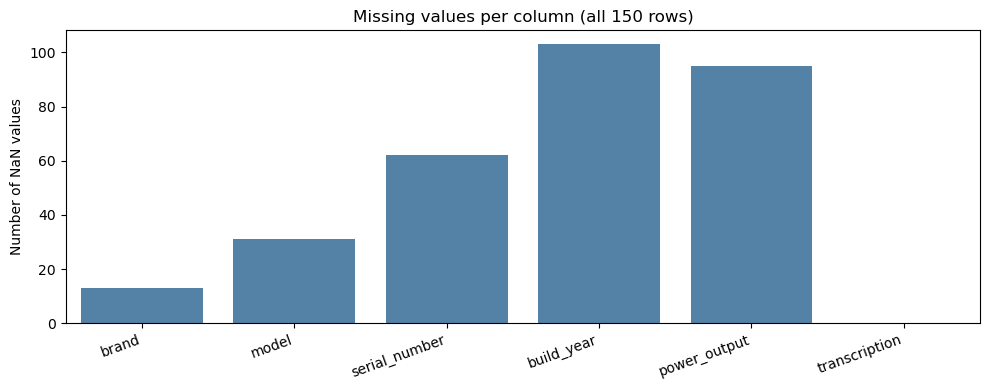

brand             13
model             31
serial_number     62
build_year       103
power_output      95
transcription      0
dtype: int64


In [7]:
nan_counts = df_raw[FIELDS + ["transcription"]].isna().sum()
plt.figure(figsize=(10, 4))
sns.barplot(x=nan_counts.index, y=nan_counts.values, color="steelblue")
plt.xticks(rotation=20, ha="right")
plt.ylabel("Number of NaN values")
plt.title("Missing values per column (all 150 rows)")
plt.tight_layout()
plt.savefig("fig_missing_values.png", dpi=150, bbox_inches='tight')
plt.show()
print(nan_counts)

In [8]:
# Filter to OK rows — these form the official evaluation set
gt = df_raw[df_raw["status"] == FILTER_STATUS].copy().reset_index(drop=True)
gt = gt.drop_duplicates(subset="filename", keep="first").reset_index(drop=True)

print(f"Total rows in Excel:           {len(df_raw)}")
print(f"Rows with status=OK (used):    {len(gt)}")
print(f"Rows with status=CHECK (excl): {len(df_raw) - len(gt)}")
print()
print("Plate type distribution (evaluation set):")
print(gt["plate_type"].value_counts())
print()
print("Readability distribution (evaluation set):")
print(gt["readability"].value_counts())

Total rows in Excel:           150
Rows with status=OK (used):    77
Rows with status=CHECK (excl): 73

Plate type distribution (evaluation set):
plate_type
sticker        40
metal_plate    28
engraved        9
Name: count, dtype: int64

Readability distribution (evaluation set):
readability
good      67
medium    10
Name: count, dtype: int64


## 2. Helper functions

### Design note on CER/WER reference
The `transcription` column contains a full manual transcription of the visible
plate text and is used as the reference string for CER and WER.
This is the correct reference because:
- It represents all readable text on the plate, not just the five structured fields
- It matches what the OCR model actually sees and outputs
- Using concatenated field values would create a shorter, incomplete reference
  that artificially inflates CER when the model outputs extra text

This approach follows Bourne et al. (2026) who define CER as edit distance
between the hypothesis (OCR output) and the full ground truth reference string.

### Design note on field-level F1
Field-level F1 uses exact string match after lowercasing and stripping whitespace.
A True Positive requires the extracted value to match the ground truth field exactly.
This is a strict criterion appropriate for industrial data where partial matches
(e.g. truncated serial numbers) are operationally useless.

In [9]:
def normalise(s):
    """Lowercase, strip whitespace. Applied to both prediction and ground truth."""
    return str(s).strip().lower().replace("nan", "")


def extract_fields(text: str) -> dict:
    """
    Heuristic regex field extraction from raw OCR output.
    
    These patterns are derived from inspection of typeplate label conventions.
    They should be reviewed and adjusted after examining the first 20 raw OCR
    outputs — typeplate layouts vary per manufacturer.
    
    Returns a dict with one key per field; empty string if not found.
    """
    patterns = {
        "brand": [
            r"(?i)(?:merk|brand|fabrikant|manufacturer|made\s*by)[:\s]+([A-Za-z0-9&\-\s\.]{2,30})",
        ],
        "model": [
            r"(?i)(?:model(?:\s*no\.?)?|type|mod\.?)[:\s]+([\w\-\/\.]{2,20})",
        ],
        "serial_number": [
            r"(?i)(?:serial(?:\s*no\.?)?|s\.?n\.?|ser\.?\s*nr\.?|serienr)[:\s]*([\w\-\/]{3,30})",
        ],
        "build_year": [
            r"(?i)(?:jaar|year(?:\s*(?:built|mfr|mfg))?|bj|baujahr|date(?:\s*of\s*m[fg]r?))[:\s]*.*?(\d{4})",
            r"\b((?:19|20)\d{2})\b",
        ],
        "power_output": [
            r"(?i)(?:vermogen|power|output)[:\s]*([\d,.]+\s*(?:kVA|KVA|kW|KW|W|HP|hp))",
            r"([\d,.]+\s*(?:kVA|KVA|kW|KW))",
        ],
    }
    result = {}
    for field, pattern_list in patterns.items():
        value = ""
        for pattern in pattern_list:
            m = re.search(pattern, text)
            if m:
                value = m.group(1).strip()
                break
        result[field] = value
    return result


def evaluate_model(gt_df, ocr_df, model_name):
    """
    Two-level evaluation of an OCR model on the typeplate testset.
    
    Level 1 — CER and WER (Bourne et al., 2026):
        Computed between the raw OCR output and the full `transcription`
        ground truth string using Levenshtein edit distance via jiwer.
    
    Level 2 — Field-level F1:
        Exact-match precision, recall, and F1 per structured field
        (brand, model, serial_number, build_year, power_output).
    
    Parameters
    ----------
    gt_df       : DataFrame with columns filename, transcription, + FIELDS
    ocr_df      : DataFrame with columns filename, raw_ocr, time_sec, error
    model_name  : string label for output
    
    Returns
    -------
    dict with all metrics for the comparison table
    """
    ocr_ok   = ocr_df[ocr_df["error"] == ""].copy().reset_index(drop=True)
    gt_eval  = gt_df[gt_df["filename"].isin(ocr_ok["filename"])].copy()
    gt_eval  = gt_eval.set_index("filename").loc[ocr_ok["filename"]].reset_index()

    n = len(gt_eval)

    # ── Level 1: CER / WER on full transcription ────────────────────────
    # Reference: transcription column (full manual plate text)
    # Hypothesis: raw OCR output
    # Both normalised to lowercase, whitespace stripped before comparison
    ref_list = gt_eval["transcription"].fillna("").astype(str).apply(normalise).tolist()
    hyp_list = ocr_ok["raw_ocr"].fillna("").astype(str).apply(normalise).tolist()

    # Filter pairs where reference is non-empty (can't compute CER on empty ref)
    valid = [(r, h) for r, h in zip(ref_list, hyp_list) if r.strip()]
    if valid:
        refs, hyps = zip(*valid)
        overall_cer = cer(list(refs), list(hyps))
        overall_wer = wer(list(refs), list(hyps))
    else:
        overall_cer = overall_wer = float("nan")

    # ── Level 2: Field-level F1 ─────────────────────────────────────────
    field_results = {}
    for field in FIELDS:
        extracted = ocr_ok["raw_ocr"].apply(
            lambda t: normalise(extract_fields(str(t)).get(field, ""))
        ).reset_index(drop=True)

        truth = gt_eval[field].fillna("").astype(str).apply(normalise).reset_index(drop=True)

        ext_arr   = extracted.to_numpy()
        truth_arr = truth.to_numpy()

        tp = int(((ext_arr == truth_arr) & (truth_arr != "")).sum())
        fp = int(((ext_arr != "") & (ext_arr != truth_arr)).sum())
        fn = int(((ext_arr == "") & (truth_arr != "")).sum())

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

        field_results[field] = {
            "precision": precision, "recall": recall, "f1": f1,
            "tp": tp, "fp": fp, "fn": fn
        }

    macro_f1 = sum(v["f1"] for v in field_results.values()) / len(FIELDS)
    avg_time  = ocr_ok["time_sec"].mean()
    max_time  = ocr_ok["time_sec"].max()

    # ── Print results ────────────────────────────────────────────────────
    print(f"\n{'='*60}")
    print(f"Model: {model_name}  |  n={n}")
    print(f"{'='*60}")
    print(f"CER: {overall_cer:.4f}  ({(1-overall_cer)*100:.1f}% char accuracy)")
    print(f"WER: {overall_wer:.4f}  ({(1-overall_wer)*100:.1f}% word accuracy)")
    print(f"\n{'Field':<22} {'P':>7} {'R':>7} {'F1':>7} {'TP':>5} {'FP':>5} {'FN':>5}")
    print("-" * 60)
    for field in FIELDS:
        r = field_results[field]
        print(f"{field:<22} {r['precision']:>7.3f} {r['recall']:>7.3f} "
              f"{r['f1']:>7.3f} {r['tp']:>5} {r['fp']:>5} {r['fn']:>5}")
    print("-" * 60)
    print(f"{'Macro-avg F1':<22} {macro_f1:>21.3f}")
    print(f"\nAvg. time: {avg_time:.3f}s | Max: {max_time:.3f}s | "
          f"Target ≤6s: {'OK' if avg_time <= 6 else 'TOO SLOW'}")

    return {
        "model": model_name, "n": n,
        "cer": round(overall_cer, 4),
        "wer": round(overall_wer, 4),
        **{f"f1_{f}": round(field_results[f]["f1"], 3) for f in FIELDS},
        "macro_f1": round(macro_f1, 3),
        "avg_time_s": round(avg_time, 3),
    }

print("Helper functions loaded.")

Helper functions loaded.


## 3. Baseline: Tesseract (PSM 6)

Replicates the approach used by Prognotice via Ivar: raw Tesseract output on unprocessed images.

**Reference:** Smith, R. (2007). An Overview of the Tesseract OCR Engine.  
*ICDAR 2007*, pp. 629–633. doi:10.1109/ICDAR.2007.4376991

**PSM 6** (Assume a single uniform block of text) is chosen as it is the standard  
mode for structured label images. PSM 11 (sparse text, no layout) is an alternative  
if results suggest Tesseract misreads the block structure.

**Windows install:** https://github.com/UB-Mannheim/tesseract/wiki

In [10]:
import pytesseract

# On Windows: uncomment and set path to tesseract.exe
pytesseract.pytesseract.tesseract_cmd = r"C:/Program Files/Tesseract-OCR/tesseract.exe"

PSM_MODE = 6

results_tesseract = []
for _, row in gt.iterrows():
    img_path = os.path.join(IMAGE_DIR, row["filename"])
    if not os.path.exists(img_path):
        results_tesseract.append({"filename": row["filename"], "raw_ocr": "", "time_sec": 0.0, "error": "not_found"})
        continue
    try:
        img = Image.open(img_path)
        t0  = time.time()
        raw = pytesseract.image_to_string(img, lang="nld+eng", config=f"--psm {PSM_MODE}")
        results_tesseract.append({"filename": row["filename"], "raw_ocr": raw.strip(),
                                   "time_sec": round(time.time()-t0, 3), "error": ""})
    except Exception as e:
        results_tesseract.append({"filename": row["filename"], "raw_ocr": "", "time_sec": 0.0, "error": str(e)})

df_tesseract = pd.DataFrame(results_tesseract)
not_found = (df_tesseract["error"] == "not_found").sum()
errors    = (df_tesseract["error"].str.len() > 0).sum()
print(f"Done. Images not found: {not_found}  |  Other errors: {errors - not_found}")

ModuleNotFoundError: No module named 'pytesseract'

In [ ]:
# Inspect first 3 raw outputs before finalising regex patterns in extract_fields()
print("=== RAW TESSERACT OUTPUT PREVIEW ===")
for _, row in df_tesseract[df_tesseract["error"]==""].head(3).iterrows():
    gt_row = gt[gt["filename"] == row["filename"]].iloc[0]
    print(f"\n--- {row['filename']} ---")
    print(f"GROUND TRUTH: {gt_row['transcription'][:150]}")
    print(f"OCR OUTPUT:   {row['raw_ocr'][:150]}")

=== RAW TESSERACT OUTPUT PREVIEW ===

--- imgi_96_s-l1200.jpg ---
GROUND TRUTH: FLOWSERVE CORP. RALEIGH, NC 27603. BOLTED BONNET SIZE 0.750. B16.34LTD. CLASS 800. CWP 2000. 1375 PSI @ 800 °F MAX. FIG A848. B/M 026012160000000. BOD
OCR OUTPUT:   WSERVE CORP. ’
B16.34LTD = * Fic Asa
CLASS 800 CwP 2000 eal ae
1375 PSI @ 800 °F MAX BONNET A105 «-.
PACKING TORQUE FT-LBS | isk 615 = a
INITIAL PRELO

--- imgi_97_s-l400.jpg ---
GROUND TRUTH: Dayton. Industrial Control Transformer. Model: 31EH75. 50VA. 50/60Hz. TEMP CL. 105°C. Made in USA/Hecho en USA/Fab. en USA. Dayton Electric Mfg. Co., 
OCR OUTPUT:   Industrial Control 4699610)
Transformer ed
Model: 31EH75
SOVA 50/60Hz TEMP CL. 105°C
(Male in USAecho en USAF ab. en USA Mi. for ab para a. pour:
Dayt

--- imgi_9_default.jpg ---
GROUND TRUTH: CAUTION. MAXIMUM PERMISSIBLE ROAD SPEED IN THE FOLLOWING GEAR POSITIONS. TRANSMISSION TRANSFER CASE IN HIGH RANGE / LOW RANGE. HIGH 65 M.P.H. / 30 M.P
OCR OUTPUT:   AUTION
MISSIBLE RO,
WING. GEAR
SYSTEM O

In [ ]:
results_summary = []
res = evaluate_model(gt, df_tesseract, f"Tesseract PSM{PSM_MODE}")
results_summary.append(res)


Model: Tesseract PSM6  |  n=77
CER: 0.7839  (21.6% char accuracy)
WER: 1.0927  (-9.3% word accuracy)

Field                        P       R      F1    TP    FP    FN
------------------------------------------------------------
brand                    0.000   0.000   0.000     0     1    70
model                    0.150   0.054   0.079     3    17    53
serial_number            0.000   0.000   0.000     0     5    50
build_year               0.000   0.000   0.000     0     8    23
power_output             0.571   0.133   0.216     4     3    26
------------------------------------------------------------
Macro-avg F1                           0.059

Avg. time: 0.465s | Max: 2.203s | Target ≤6s: OK


## 4. Candidate model 1: EasyOCR

Deep learning OCR using a CRNN + CTC architecture.  
Strong on varied fonts, scene text, and multiple languages without layout assumptions.

**Reference:** JaidedAI (2020). EasyOCR: Ready-to-use OCR with 80+ supported languages.  
https://github.com/JaidedAI/EasyOCR

**Install:** `pip install easyocr`

In [ ]:
!pip install easyocr
import easyocr

# gpu=False for offline CPU use. Set gpu=True if a CUDA GPU is available.
reader_easy = easyocr.Reader(["nl", "en"], gpu=False)
print("EasyOCR loaded.")

  Using cached easyocr-1.7.2-py3-none-any.whl (2.9 MB)
     ---------------------------------------- 3.4/3.4 MB 463.4 kB/s eta 0:00:00
     ------------------------------------ 310.0/310.0 kB 144.2 kB/s eta 0:00:00
     ------------------------------------ 104.2/104.2 kB 286.5 kB/s eta 0:00:00
     -------------------------------------- 40.1/40.1 MB 596.3 kB/s eta 0:00:00
     -------------------------------------- 166.3/166.3 kB 1.7 MB/s eta 0:00:00
     -------------------------------------- 122.9/122.9 MB 4.3 MB/s eta 0:00:00
     ---------------------------------------- 6.3/6.3 MB 4.6 MB/s eta 0:00:00
     ---------------------------------------- 12.9/12.9 MB 3.0 MB/s eta 0:00:00
     ---------------------------------------- 41.3/41.3 MB 3.9 MB/s eta 0:00:00
  Attempting uninstall: sympy
    Found existing installation: sympy 1.13.1
    Uninstalling sympy-1.13.1:
      Successfully uninstalled sympy-1.13.1
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4


ERROR: Could not install packages due to an OSError: [WinError 5] Toegang geweigerd: 'C:\\Users\\mitch\\anaconda3\\Lib\\site-packages\\~umpy.libs\\libopenblas64__v0.3.23-293-gc2f4bdbb-gcc_10_3_0-2bde3a66a51006b2b53eb373ff767a3f.dll'
Consider using the `--user` option or check the permissions.



ModuleNotFoundError: No module named 'easyocr'

In [ ]:
results_easy = []
for _, row in gt.iterrows():
    img_path = os.path.join(IMAGE_DIR, row["filename"])
    if not os.path.exists(img_path):
        results_easy.append({"filename": row["filename"], "raw_ocr": "", "time_sec": 0.0, "error": "not_found"})
        continue
    try:
        t0  = time.time()
        raw = " ".join(reader_easy.readtext(img_path, detail=0))
        results_easy.append({"filename": row["filename"], "raw_ocr": raw.strip(),
                              "time_sec": round(time.time()-t0, 3), "error": ""})
    except Exception as e:
        results_easy.append({"filename": row["filename"], "raw_ocr": "", "time_sec": 0.0, "error": str(e)})

df_easy = pd.DataFrame(results_easy)
print(f"Done. Errors: {(df_easy['error'] != '').sum()}")

In [ ]:
res = evaluate_model(gt, df_easy, "EasyOCR")
results_summary.append(res)

## 5. Candidate model 2: PaddleOCR

Two-stage pipeline: DB text detection + SVTR recognition.  
Designed for offline, resource-constrained industrial deployment.

**References:**  
Du et al. (2020). PP-OCR: A Practical Ultra Lightweight OCR System. arXiv:2009.09941  
Du et al. (2021). PP-OCRv2: Bag of Tricks. arXiv:2109.03144  
Li et al. (2022). PP-OCRv3. arXiv:2206.03001

**Install:** `pip install paddleocr paddlepaddle`

In [ ]:
from paddleocr import PaddleOCR

ocr_paddle = PaddleOCR(use_angle_cls=True, lang="en", use_gpu=False, show_log=False)
print("PaddleOCR loaded.")

In [ ]:
results_paddle = []
for _, row in gt.iterrows():
    img_path = os.path.join(IMAGE_DIR, row["filename"])
    if not os.path.exists(img_path):
        results_paddle.append({"filename": row["filename"], "raw_ocr": "", "time_sec": 0.0, "error": "not_found"})
        continue
    try:
        t0     = time.time()
        result = ocr_paddle.ocr(img_path, cls=True)
        raw    = " ".join([line[1][0] for line in result[0]]) if result and result[0] else ""
        results_paddle.append({"filename": row["filename"], "raw_ocr": raw.strip(),
                                "time_sec": round(time.time()-t0, 3), "error": ""})
    except Exception as e:
        results_paddle.append({"filename": row["filename"], "raw_ocr": "", "time_sec": 0.0, "error": str(e)})

df_paddle = pd.DataFrame(results_paddle)
print(f"Done. Errors: {(df_paddle['error'] != '').sum()}")

In [ ]:
res = evaluate_model(gt, df_paddle, "PaddleOCR")
results_summary.append(res)

## 6. Comparison and visualisation

In [ ]:
df_results = pd.DataFrame(results_summary).set_index("model")
print("Full comparison table:")
display(df_results)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

df_results["cer"].plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("Character Error Rate (CER)\nlower is better")
axes[0].set_ylabel("CER")
axes[0].set_ylim(0, max(df_results["cer"].max() * 1.2, 1))
axes[0].tick_params(axis='x', rotation=15)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.3f}", (p.get_x()+p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

df_results["macro_f1"].plot(kind="bar", ax=axes[1], color="coral", edgecolor="black")
axes[1].set_title("Macro-average Field F1\nhigher is better")
axes[1].set_ylabel("F1")
axes[1].set_ylim(0, 1)
axes[1].axhline(y=0.75, color="green", linestyle="--", linewidth=1.2, label="Target (0.75)")
axes[1].legend(fontsize=8)
axes[1].tick_params(axis='x', rotation=15)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.3f}", (p.get_x()+p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

df_results["avg_time_s"].plot(kind="bar", ax=axes[2], color="seagreen", edgecolor="black")
axes[2].axhline(y=6, color="red", linestyle="--", linewidth=1.5, label="Target (6s)")
axes[2].set_title("Avg. processing time (s)\ntarget ≤ 6s")
axes[2].set_ylabel("Seconds")
axes[2].legend(fontsize=8)
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle("OCR Model Comparison — Typeplate Testset", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("fig_ocr_comparison_summary.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Field-level F1 heatmap
f1_cols = [c for c in df_results.columns if c.startswith("f1_")]
df_f1 = df_results[f1_cols].copy()
df_f1.columns = [c.replace("f1_", "") for c in df_f1.columns]

plt.figure(figsize=(9, 4))
sns.heatmap(df_f1, annot=True, fmt=".3f", cmap="RdYlGn",
            vmin=0, vmax=1, linewidths=0.5, linecolor="white")
plt.title("Field-level F1 score per model", fontsize=12, fontweight='bold')
plt.ylabel("Model")
plt.tight_layout()
plt.savefig("fig_ocr_f1_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# CER per plate_type per model
model_pairs = [
    (f"Tesseract PSM{PSM_MODE}", df_tesseract),
    ("EasyOCR",   df_easy),
    ("PaddleOCR", df_paddle),
]

plate_types = sorted(gt["plate_type"].dropna().unique())
cer_by_type = {}

for model_name, ocr_df in model_pairs:
    ocr_ok  = ocr_df[ocr_df["error"] == ""]
    gt_eval = gt[gt["filename"].isin(ocr_ok["filename"])].copy()
    gt_eval = gt_eval.set_index("filename").loc[ocr_ok["filename"].values].reset_index()

    row_dict = {}
    for ptype in plate_types:
        idx = gt_eval[gt_eval["plate_type"] == ptype].index
        refs = gt_eval.loc[idx, "transcription"].fillna("").astype(str).apply(normalise).tolist()
        hyps = ocr_ok.reset_index(drop=True).loc[idx, "raw_ocr"].fillna("").astype(str).apply(normalise).tolist()
        valid = [(r,h) for r,h in zip(refs,hyps) if r.strip()]
        if valid:
            r_l, h_l = zip(*valid)
            row_dict[ptype] = round(cer(list(r_l), list(h_l)), 4)
        else:
            row_dict[ptype] = float("nan")
    cer_by_type[model_name] = row_dict

df_cer_type = pd.DataFrame(cer_by_type).T

df_cer_type.plot(kind="bar", figsize=(10, 5), edgecolor="black")
plt.title("CER per plate type per model", fontsize=12, fontweight='bold')
plt.ylabel("CER  (lower = better)")
plt.xticks(rotation=15)
plt.legend(title="Plate type")
plt.tight_layout()
plt.savefig("fig_ocr_cer_by_platetype.png", dpi=150, bbox_inches='tight')
plt.show()
print(df_cer_type.to_string())

## 7. Export results

In [ ]:
df_results.to_csv("ocr_results_summary.csv")
df_tesseract.to_csv(f"output_tesseract_psm{PSM_MODE}.csv", index=False)
df_easy.to_csv("output_easyocr.csv", index=False)
df_paddle.to_csv("output_paddleocr.csv", index=False)
print("All outputs saved.")
display(df_results)